This notebook generates Figure 7 in the manuscript.

In [70]:
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import pickle as pkl
import skimage
import yaml
from typing import Union, Optional, Type, Tuple, List, Dict
import sys
from skimage.color import label2rgb
import json
# import nrrd

import pandas as pd
import seaborn as sns
# Project Root
# used for searching packages and functions
# TODO: enter your project root dir here
ROOT_DIR = '/project/Xie_Lab/zgu/xiao_multiplex/multiTAP/image_cytof'

sys.path.append(ROOT_DIR)
sys.path.append(os.path.join(ROOT_DIR, 'image_cytof'))
from cytof.hyperion_preprocess import cytof_read_data_roi
from cytof.utils import save_multi_channel_img, check_feature_distribution
from cytof.classes import CytofImageTiff
from cytof.classes import CytofCohort


# fig 7a
spatial interaction at marker level

In [87]:
# concatenate all files 
SAVED_GROUPS = [86, 87, 88, 175, 176, 178]
# SAVED_GROUPS = [88, 178]

BASE_CSV_DIR = "/project/Xie_Lab/zgu/xiao_multiplex/nsclc_multiTAP_work"
THRESHOLD = 15 # [50, 100, None]
METHOD = 'k-neighbor' # ["distance", "k-neighbor", None]
accumul_type = 'sum'

# combine individual save groups as one
df_list = []
for prefix in SAVED_GROUPS:
    if THRESHOLD and METHOD:
        csv_path = os.path.join(BASE_CSV_DIR, f"nsclc_save_group{prefix}", f"nsclc_save_group{prefix}_2d_spatial_interaction_thresh_{THRESHOLD}_method_{METHOD}_accuml_{accumul_type}.csv")

    else: 
        csv_path = os.path.join(BASE_CSV_DIR, f"nsclc_save_group{prefix}", f"nsclc_save_group{prefix}_flattened_spatial.csv")
    df = pd.read_csv(csv_path, index_col=0)

    df_list.append(df)

combined_spatial_df = pd.concat(df_list).reset_index(names='from')

# 0 is used to indicate not observed, but average over will skew the df
spatial_pt_df = combined_spatial_df.replace(0, np.nan)
spatial_pt_df

,from,Myelope_276((2996))Y89-Y89_cell_sum,FSP1 S1_2263((3411))In113-In113_cell_sum,SMA_174((3277))In115-In115_cell_sum,117Sn-Sn117_cell_sum,Histone_126((2797))Pr141-Pr141_cell_sum,fap_323((3412))Nd142-Nd142_cell_sum,HLA-DR_1849((3362))Nd143-Nd143_cell_sum,CD146_22((3259))Nd144-Nd144_cell_sum,Cadheri_2088((2893))Nd145-Nd145_cell_sum,...,CD31_1859((3370))Yb172-Yb172_cell_sum,anti-Hu_1950((2832))Yb173-Yb173_cell_sum,CCL21 6_2177((2889))Yb174-Yb174_cell_sum,panCyto_234((2745))Lu175-Lu175_cell_sum,K-Cadhe_2600((3417))Yb176-Yb176_cell_sum,Ki-67_142((3418))Pt194-Pt194_cell_sum,Caveoli_1945((2899))Pt195-Pt195_cell_sum,206Pb-Pb206_cell_sum,CD15_627((2997))Bi209-Bi209_cell_sum,roi_id
0,Myelope_276((2996))Y89-Y89_cell_sum,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NSCLC_ALL_86_A_A1_1
1,FSP1 S1_2263((3411))In113-In113_cell_sum,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.221079,NaN,0.249745,NaN,NaN,-0.664031,NaN,NaN,NSCLC_ALL_86_A_A1_1
2,SMA_174((3277))In115-In115_cell_sum,NaN,NaN,-0.117697,NaN,-1.199579,-0.499427,NaN,-0.588036,-0.083934,...,-0.639094,-0.877420,-0.261258,-0.773599,NaN,-0.648608,-0.485418,-1.022082,-1.185348,NSCLC_ALL_86_A_A1_1
3,117Sn-Sn117_cell_sum,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NSCLC_ALL_86_A_A1_1
4,Histone_126((2797))Pr141-Pr141_cell_sum,NaN,NaN,-1.266525,NaN,0.243456,-0.892645,NaN,NaN,NaN,...,NaN,0.243678,NaN,0.243814,0.059981,-0.554969,-0.338125,-0.561691,0.283853,NSCLC_ALL_86_A_A1_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83845,K-Cadhe_2600((3417))Yb176-Yb176_cell_sum,-0.511701,NaN,-0.300640,-0.233130,-0.414992,-0.333511,-0.467279,-0.345933,-0.328095,...,-0.321202,-0.198115,-0.226234,-0.520880,-0.198276,NaN,-0.397455,-0.511701,-0.447242,NSCLC_ALL_178_C_C_4_15
83846,Ki-67_142((3418))Pt194-Pt194_cell_sum,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NSCLC_ALL_178_C_C_4_15
83847,Caveoli_1945((2899))Pt195-Pt195_cell_sum,NaN,NaN,-0.258286,-0.492929,-0.265284,NaN,NaN,-0.059613,-0.117937,...,-0.155269,-0.346786,-0.315629,NaN,-0.397455,NaN,NaN,NaN,NaN,NSCLC_ALL_178_C_C_4_15
83848,206Pb-Pb206_cell_sum,NaN,NaN,NaN,-0.377640,-0.525189,NaN,0.275141,NaN,NaN,...,NaN,-0.403036,-0.386944,0.463229,-0.379076,NaN,NaN,NaN,0.142549,NSCLC_ALL_178_C_C_4_15


In [88]:
marker_cols = spatial_pt_df.columns[spatial_pt_df.columns.str.contains('cell_sum')]

# average across patients for each cell type
grouped_spatial = spatial_pt_df.groupby(["from"])[marker_cols].mean(numeric_only=False)

# now, fill na with 0 temprary (ideally separate out in the cluster maps)
grouped_spatial = grouped_spatial.fillna(0)
grouped_spatial

,Myelope_276((2996))Y89-Y89_cell_sum,FSP1 S1_2263((3411))In113-In113_cell_sum,SMA_174((3277))In115-In115_cell_sum,117Sn-Sn117_cell_sum,Histone_126((2797))Pr141-Pr141_cell_sum,fap_323((3412))Nd142-Nd142_cell_sum,HLA-DR_1849((3362))Nd143-Nd143_cell_sum,CD146_22((3259))Nd144-Nd144_cell_sum,Cadheri_2088((2893))Nd145-Nd145_cell_sum,Carboni_2443((2757))Nd146-Nd146_cell_sum,...,CD4_2293((3000))Yb171-Yb171_cell_sum,CD31_1859((3370))Yb172-Yb172_cell_sum,anti-Hu_1950((2832))Yb173-Yb173_cell_sum,CCL21 6_2177((2889))Yb174-Yb174_cell_sum,panCyto_234((2745))Lu175-Lu175_cell_sum,K-Cadhe_2600((3417))Yb176-Yb176_cell_sum,Ki-67_142((3418))Pt194-Pt194_cell_sum,Caveoli_1945((2899))Pt195-Pt195_cell_sum,206Pb-Pb206_cell_sum,CD15_627((2997))Bi209-Bi209_cell_sum
from,,,,,,,,,,,,,,,,,,,,,
117Sn-Sn117_cell_sum,-0.433674,-0.422769,-0.328464,-0.279453,-0.465403,-0.400793,-0.408658,-0.408229,-0.390540,-0.418492,...,-0.436004,-0.393736,-0.461077,-0.421657,-0.377242,-0.467732,-0.431294,-0.411789,-0.420213,-0.405732
206Pb-Pb206_cell_sum,-0.315659,-0.078996,-0.450797,-0.371536,-0.392511,-0.357364,-0.368941,-0.368966,-0.321899,-0.221023,...,-0.070145,-0.372459,-0.153317,-0.013505,-0.374083,0.106817,-0.340897,-0.365148,0.240906,-0.387821
CCL21 6_2177((2889))Yb174-Yb174_cell_sum,-0.219566,-0.172815,-0.448353,-0.407623,-0.489909,-0.420714,-0.381872,-0.432154,-0.401338,-0.406389,...,-0.154780,-0.337260,-0.129285,0.349228,-0.478135,0.008791,-0.490927,-0.464739,-0.029403,-0.352918
CD10_2546((3029))Dy161-Dy161_cell_sum,-0.436391,-0.414834,-0.477683,-0.401331,-0.554062,-0.409760,-0.375222,-0.458828,-0.513286,-0.450745,...,-0.328192,-0.437237,-0.505472,-0.396703,-0.509668,-0.432368,-0.502911,-0.443422,-0.370400,-0.457126
CD140b(_1938((2914))Tm169-Tm169_cell_sum,-0.535266,-0.455960,-0.333654,-0.404977,-0.538783,-0.385932,-0.485640,-0.374546,-0.397252,-0.514959,...,-0.407100,-0.393353,-0.519488,-0.459695,-0.483838,-0.418981,-0.481544,-0.430442,-0.438848,-0.524736
CD146_22((3259))Nd144-Nd144_cell_sum,-0.494636,-0.404213,-0.245045,-0.401722,-0.592827,-0.398320,-0.392762,-0.067108,-0.289939,-0.511151,...,-0.360094,-0.172052,-0.489378,-0.436436,-0.534412,-0.390443,-0.494886,-0.352894,-0.404841,-0.554580
CD15_627((2997))Bi209-Bi209_cell_sum,-0.153534,-0.463495,-0.616821,-0.393130,-0.405037,-0.495281,-0.542390,-0.545117,-0.603238,-0.366787,...,-0.500626,-0.519079,-0.375718,-0.358148,-0.298404,-0.378180,-0.486950,-0.493764,-0.428920,0.048914
CD20_36((3369))Sm149-Sm149_cell_sum,-0.533668,-0.316418,-0.448896,-0.423216,-0.645962,-0.513609,-0.357322,-0.477448,-0.517984,-0.619661,...,-0.261947,-0.436215,-0.572221,-0.317193,-0.649906,-0.371676,-0.573329,-0.536144,-0.337177,-0.621102
CD248 E_2178((2830))Er167-Er167_cell_sum,-0.455365,-0.429814,-0.383116,-0.393138,-0.468047,-0.397471,-0.475707,-0.382214,-0.339948,-0.390798,...,-0.380270,-0.404303,-0.450750,-0.440217,-0.392744,-0.360073,-0.425111,-0.380963,-0.388001,-0.416631


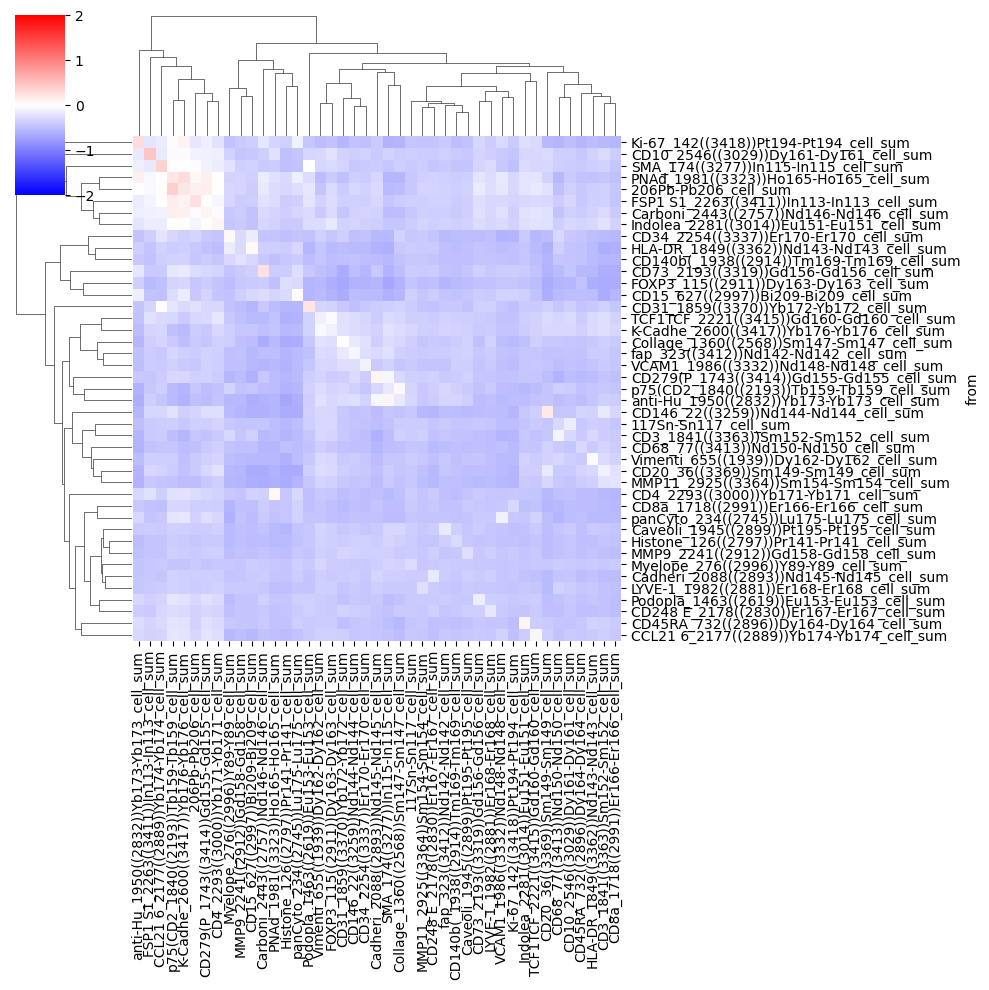

In [89]:

%matplotlib inline
epsilon = 1e-6

clustergrid = sns.clustermap(grouped_spatial,
                            # clustergrid = sns.clustermap(edge_percentage_norm,
                            center=np.log10(1 + epsilon), cmap='bwr', vmin=-2, vmax=2,
                            xticklabels=grouped_spatial.columns, yticklabels=grouped_spatial.columns)
plt.show()

In [37]:
def unflatten_to_dict(df, id_col="ROI_ID", pair_sep="_TO_", aggfunc="first"):
    pair_cols = [c for c in df.columns if pair_sep in c]

    long_df = df.melt(id_vars=[id_col], value_vars=pair_cols,
                      var_name="pair", value_name="value")
    long_df[["from", "to"]] = long_df["pair"].str.split(pair_sep, expand=True)

    labels = sorted(set(long_df["from"]).union(long_df["to"]))
    out = {}

    # group by ROI and pivot within each group
    for roi, g in long_df.groupby(id_col, sort=False):
        mat = g.pivot_table(index="from", columns="to",
                            values="value", aggfunc=aggfunc)
        # enforce square order and fill any missing pairs
        mat = mat.reindex(index=labels, columns=labels)

        mat = clean_matrix(mat, "cell_sum")
        out[roi] = mat

    return out


def clean_matrix(mat: pd.DataFrame, keyword: str) -> pd.DataFrame:
    # Drop rows where index contains keyword
    mat = mat[~mat.index.str.contains(keyword, na=False)]
    
    # Keep only columns containing keyword
    mat = mat.loc[:, mat.columns.str.contains(keyword, na=False)]
    
    return mat


In [ ]:
# revert the previously flattened matrix
matrices = unflatten_to_dict(combined_spatial_df, id_col="ROI_ID", pair_sep="_cell_sum_to_")


In [ ]:
# some quick QC checks
print(len(matrices.keys()))
matrices['87_B_B8_14'].head()


1951


to,117Sn-Sn117_cell_sum,206Pb-Pb206_cell_sum,CCL21 6_2177((2889))Yb174-Yb174_cell_sum,CD10_2546((3029))Dy161-Dy161_cell_sum,CD140b(_1938((2914))Tm169-Tm169_cell_sum,CD146_22((3259))Nd144-Nd144_cell_sum,CD15_627((2997))Bi209-Bi209_cell_sum,CD20_36((3369))Sm149-Sm149_cell_sum,CD248 E_2178((2830))Er167-Er167_cell_sum,CD279(P_1743((3414))Gd155-Gd155_cell_sum,...,PNAd_1981((3323))Ho165-Ho165_cell_sum,Podopla_1463((2619))Eu153-Eu153_cell_sum,SMA_174((3277))In115-In115_cell_sum,TCF1TCF_2221((3415))Gd160-Gd160_cell_sum,VCAM1_1986((3332))Nd148-Nd148_cell_sum,Vimenti_655((1939))Dy162-Dy162_cell_sum,anti-Hu_1950((2832))Yb173-Yb173_cell_sum,fap_323((3412))Nd142-Nd142_cell_sum,p75(CD2_1840((2193))Tb159-Tb159_cell_sum,panCyto_234((2745))Lu175-Lu175_cell_sum
from,,,,,,,,,,,,,,,,,,,,,
117Sn-Sn117,-0.375516,-0.272899,-0.491986,-0.378894,-0.398983,-0.409340,-0.362398,-0.468826,-0.367273,-0.452312,...,-0.396715,-0.347805,-0.327886,-0.440303,-0.431633,-0.303195,-0.499972,-0.363843,-0.343958,-0.298564
206Pb-Pb206,-0.291124,0.141108,-0.385774,-0.240087,-0.340357,-0.425358,-0.469038,-0.660261,-0.438647,-0.518682,...,-0.380871,-0.794786,-0.317587,-0.647929,-0.536812,-0.295386,0.000000,-0.411393,0.000000,-0.427269
CCL21 6_2177((2889))Yb174-Yb174,-0.469420,-0.385774,0.532455,-0.303887,-0.331301,-0.270692,-0.625128,-0.111408,-0.276043,-0.184560,...,0.000000,0.199875,-0.145795,-0.377935,-1.010425,-0.144025,-0.224669,-0.205392,0.000000,-0.965866
CD10_2546((3029))Dy161-Dy161,-0.373931,-0.253875,-0.285789,-0.300432,-0.335176,-0.409405,-0.309614,-0.434260,-0.294417,-0.340946,...,-0.371616,-0.241695,-0.282040,-0.414204,-0.443197,-0.283709,-0.307303,-0.279617,-0.403129,-0.380552
CD140b(_1938((2914))Tm169-Tm169,-0.390990,-0.363838,-0.331301,-0.327811,-0.295971,-0.381224,-0.278160,-0.504355,-0.278044,-0.309813,...,-0.355315,-0.224700,-0.264880,-0.463535,-0.382443,-0.318956,-0.530481,-0.289466,-0.239321,-0.348283


In [69]:
df_marker_spatial

,ROI_ID,from,117Sn-Sn117,206Pb-Pb206,CCL21 6_2177((2889))Yb174-Yb174,CD10_2546((3029))Dy161-Dy161,CD140b(_1938((2914))Tm169-Tm169,CD146_22((3259))Nd144-Nd144,CD15_627((2997))Bi209-Bi209,CD20_36((3369))Sm149-Sm149,...,PNAd_1981((3323))Ho165-Ho165,Podopla_1463((2619))Eu153-Eu153,SMA_174((3277))In115-In115,TCF1TCF_2221((3415))Gd160-Gd160,VCAM1_1986((3332))Nd148-Nd148,Vimenti_655((1939))Dy162-Dy162,anti-Hu_1950((2832))Yb173-Yb173,fap_323((3412))Nd142-Nd142,p75(CD2_1840((2193))Tb159-Tb159,panCyto_234((2745))Lu175-Lu175
0,86_A_A1_1,117Sn-Sn117,NaN,NaN,NaN,NaN,-0.758127,0.699390,NaN,NaN,...,NaN,NaN,-1.150141,NaN,NaN,0.084457,NaN,NaN,NaN,NaN
1,86_A_A1_1,206Pb-Pb206,NaN,-0.355260,-0.554241,-0.482088,-0.711955,0.188583,-1.096635,-0.232094,...,NaN,0.084138,-0.646254,-0.218932,-0.143435,-0.064170,-1.259650,-0.718391,NaN,-0.777518
2,86_A_A1_1,CCL21 6_2177((2889))Yb174-Yb174,NaN,-0.554241,0.450817,-0.680824,-0.558520,NaN,NaN,-0.131339,...,-0.362037,NaN,-0.282411,NaN,-0.343094,-0.661259,-0.856426,-0.315534,NaN,-1.152311
3,86_A_A1_1,CD10_2546((3029))Dy161-Dy161,NaN,-0.385178,-0.805762,-0.269718,-0.654456,-0.835765,-0.723563,-0.479865,...,-0.649176,-0.163456,-0.507261,-0.402147,-0.393114,-0.412326,-0.710253,-0.300475,NaN,-0.472489
4,86_A_A1_1,CD140b(_1938((2914))Tm169-Tm169,-0.758127,-0.711955,-0.558520,-0.711183,-0.304979,NaN,-0.076822,-0.187019,...,-0.343924,-0.870614,-0.670878,-0.273059,-0.401219,-1.119332,-0.118487,-0.530370,NaN,-0.012810
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83888,178_B_2_B_8_18,Vimenti_655((1939))Dy162-Dy162,NaN,NaN,NaN,-0.605790,-0.951725,-0.427573,-0.574750,-0.373279,...,-1.004109,-0.703633,-0.349340,-0.839671,NaN,NaN,-0.382903,-0.655786,NaN,NaN
83889,178_B_2_B_8_18,anti-Hu_1950((2832))Yb173-Yb173,NaN,-1.893838,NaN,-0.711777,-0.756788,-0.643127,-0.364216,-0.360074,...,0.197894,-1.462187,-0.523951,-0.484752,NaN,-0.683932,0.578771,-0.570005,-0.49262,0.355712
83890,178_B_2_B_8_18,fap_323((3412))Nd142-Nd142,-0.300463,-0.228091,0.050147,-0.348703,-0.823414,-0.299594,0.004770,-0.666431,...,-0.736252,-0.675218,-0.410070,-0.793252,-0.499551,-0.257848,-0.512013,0.072696,-0.76500,-0.843575
83891,178_B_2_B_8_18,p75(CD2_1840((2193))Tb159-Tb159,NaN,NaN,NaN,-0.113015,-0.282797,-0.934537,-0.859940,-0.549177,...,NaN,-0.512274,-0.503851,-0.648035,NaN,NaN,-0.492620,-0.765000,NaN,NaN


In [ ]:
# concatenate by roi_id and from marker
df_marker_spatial = pd.concat(matrices, names=["ROI_ID", "from"])

# make consistent naming
df_marker_spatial.columns = [col.replace('_cell_sum','') for col in df_marker_spatial.columns]
df_marker_spatial = df_marker_spatial.reset_index()

# 0 is used to indicate not observed, but average over will skew the df
df_marker_spatial = df_marker_spatial.replace(0, np.nan)

# average across patients for each cell type
grouped_spatial = df_marker_spatial.groupby(["from"])[df_marker_spatial.columns].mean(numeric_only=False)
grouped_spatial

/tmp/ipykernel_979246/3408635950.py:11: FutureWarning: Dropping invalid columns in DataFrameGroupBy.mean is deprecated. In a future version, a TypeError will be raised. Before calling .mean, select only columns which should be valid for the function.
  grouped_spatial = df_marker_spatial.groupby(["from"])[df_marker_spatial.columns].mean(numeric_only=False)


,117Sn-Sn117,206Pb-Pb206,CCL21 6_2177((2889))Yb174-Yb174,CD10_2546((3029))Dy161-Dy161,CD140b(_1938((2914))Tm169-Tm169,CD146_22((3259))Nd144-Nd144,CD15_627((2997))Bi209-Bi209,CD20_36((3369))Sm149-Sm149,CD248 E_2178((2830))Er167-Er167,CD279(P_1743((3414))Gd155-Gd155,...,PNAd_1981((3323))Ho165-Ho165,Podopla_1463((2619))Eu153-Eu153,SMA_174((3277))In115-In115,TCF1TCF_2221((3415))Gd160-Gd160,VCAM1_1986((3332))Nd148-Nd148,Vimenti_655((1939))Dy162-Dy162,anti-Hu_1950((2832))Yb173-Yb173,fap_323((3412))Nd142-Nd142,p75(CD2_1840((2193))Tb159-Tb159,panCyto_234((2745))Lu175-Lu175
from,,,,,,,,,,,,,,,,,,,,,
117Sn-Sn117,-0.276654,-0.416195,-0.418265,-0.414826,-0.418018,-0.414173,-0.421359,-0.431049,-0.422565,-0.455601,...,-0.444779,-0.410896,-0.334889,-0.445335,-0.453241,-0.332559,-0.463611,-0.412037,-0.455130,-0.400416
206Pb-Pb206,-0.366016,0.257762,-0.001902,-0.345148,-0.402066,-0.384407,-0.396922,-0.301223,-0.358747,0.014844,...,-0.246482,-0.224484,-0.465173,-0.296853,-0.329375,-0.365563,-0.123867,-0.375170,0.201891,-0.350559
CCL21 6_2177((2889))Yb174-Yb174,-0.404931,-0.030282,0.368470,-0.414581,-0.462934,-0.436544,-0.380832,-0.307531,-0.455551,-0.094790,...,-0.401879,-0.046608,-0.452256,-0.336734,-0.436921,-0.319969,-0.106987,-0.433014,0.110853,-0.459145
CD10_2546((3029))Dy161-Dy161,-0.406731,-0.382974,-0.418207,-0.167370,-0.443263,-0.457868,-0.458068,-0.454275,-0.447048,-0.398336,...,-0.515718,-0.391038,-0.480346,-0.421486,-0.515130,-0.317209,-0.536775,-0.413727,-0.397164,-0.516604
CD140b(_1938((2914))Tm169-Tm169,-0.412226,-0.453290,-0.472577,-0.446621,-0.297783,-0.380367,-0.524385,-0.521830,-0.453062,-0.438417,...,-0.541429,-0.426583,-0.334046,-0.462642,-0.478339,-0.364794,-0.524401,-0.392867,-0.400563,-0.489331
CD146_22((3259))Nd144-Nd144,-0.410602,-0.420532,-0.445896,-0.463808,-0.384149,-0.081156,-0.562342,-0.479683,-0.400391,-0.397329,...,-0.518523,-0.504851,-0.257465,-0.452405,-0.474865,-0.280987,-0.495050,-0.411093,-0.330467,-0.539686
CD15_627((2997))Bi209-Bi209,-0.407828,-0.436387,-0.380007,-0.455160,-0.513464,-0.548398,0.037196,-0.628347,-0.425308,-0.489511,...,-0.382595,-0.584130,-0.620661,-0.547310,-0.520459,-0.464740,-0.397532,-0.499837,-0.418677,-0.299759
CD20_36((3369))Sm149-Sm149,-0.429651,-0.323558,-0.319273,-0.463148,-0.529902,-0.488621,-0.638977,0.181462,-0.571569,-0.265888,...,-0.589605,-0.384415,-0.449509,-0.409509,-0.534488,-0.316545,-0.555594,-0.525286,-0.212666,-0.645162
CD248 E_2178((2830))Er167-Er167,-0.405970,-0.392128,-0.445408,-0.436148,-0.437216,-0.386122,-0.422561,-0.549106,-0.199143,-0.394138,...,-0.444353,-0.466381,-0.387553,-0.492732,-0.465953,-0.389701,-0.463680,-0.398027,-0.364058,-0.402115


In [92]:
clean_spatial_cols = [cell_type.replace('_cell_sum', '') for cell_type in grouped_spatial.columns]


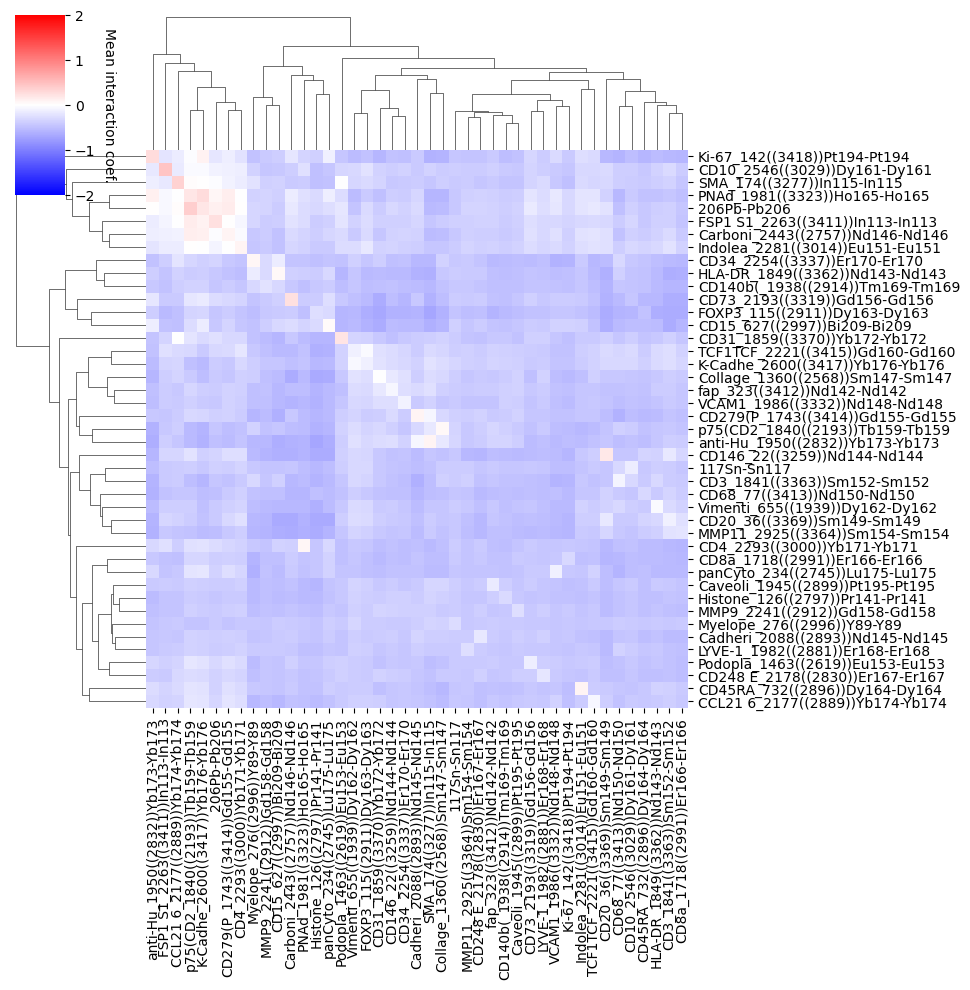

In [94]:

%matplotlib inline
epsilon = 1e-6

clustergrid = sns.clustermap(grouped_spatial,
                            # clustergrid = sns.clustermap(edge_percentage_norm,
                            center=np.log10(1 + epsilon), cmap='bwr', vmin=-2, vmax=2,
                            xticklabels=clean_spatial_cols, yticklabels=clean_spatial_cols)

# Remove y-axis label (index name from pandas DataFrame)
clustergrid.ax_heatmap.set_ylabel("")

# Add label to colorbar
clustergrid.cax.set_ylabel("Mean interaction coef.", rotation=270, labelpad=15)
# plt.savefig(os.path.join(BASE_CSV_DIR, 'supp_fig2.pdf'), format='pdf', dpi=300)

plt.show()

# suppl.

In [42]:
# QC for reconstructed vs. original interaction terms
from itertools import permutations
all_marker_combo = list(permutations(matrices['86_A_A1_1'].index, r=2))
roi_ids = combined_spatial_df['ROI_ID']

for roi_id in roi_ids:
    print(roi_id)

    # for all combinations, check the original flatten df value and the 43x43 martrix have the same values
    for marker_a, marker_b in all_marker_combo:
        check_col = f"{marker_a}_cell_sum_to_{marker_b}_cell_sum"
        
        original_val = combined_spatial_df[combined_spatial_df['ROI_ID']==roi_id][check_col].values[0]
        reconstruct_val = matrices[roi_id].loc[marker_a, f"{marker_b}_cell_sum"]

        try:
            assert np.isclose(original_val, reconstruct_val)

        except AssertionError:
            print(original_val, reconstruct_val)
            raise AssertionError

86_A_A1_1
86_A_A1_2
86_A_A1_5
86_A_A1_6
86_A_A1_7
86_A_A1_8
86_A_A1_9
86_A_A1_10
86_A_A1_11
86_A_A1_13
86_A_A1_14
86_A_A2_1
86_A_A2_2
86_A_A2_3
86_A_A2_4
86_A_A2_5
86_A_A2_6
86_A_A2_7
86_A_A2_8
86_A_A2_9
86_A_A2_10
86_A_A2_11
86_A_A2_12
86_A_A2_13
86_A_A2_14
86_A_A3_2
86_A_A3_3
86_A_A3_5
86_A_A3_6
86_A_A3_8
86_A_A3_9
86_A_A3_10
86_A_A3_11
86_A_A3_12
86_A_A3_13
86_A_A3_14
86_A_A4_2
86_A_A4_4
86_A_A4_5
86_A_A4_7
86_A_A4_8
86_A_A4_9
86_A_A4_10
86_A_A4_11
86_A_A4_12
86_A_A4_13
86_A_A4_14
86_A_A5_3
86_A_A5_4
86_A_A5_5
86_A_A5_6
86_A_A5_7
86_A_A5_8
86_A_A5_9
86_A_A5_10
86_A_A5_11
86_A_A5_12
86_A_A5_14
86_A_A6_1
86_A_A6_3
86_A_A6_4
86_A_A6_5
86_A_A6_6
86_A_A6_7
86_A_A6_8
86_A_A6_9
86_A_A6_10
86_A_A6_11
86_A_A6_12
86_A_A6_13
86_A_A6_14
86_A_A7_1
86_A_A7_2
86_A_A7_4
86_A_A7_5
86_A_A7_7
86_A_A7_8
86_A_A7_9
86_A_A7_10
86_A_A7_11
86_A_A7_12
86_A_A7_13
86_A_A8_1
86_A_A8_2
86_A_A8_3
86_A_A8_4
86_A_A8_5
86_A_A8_6
86_A_A8_7
86_A_A8_8
86_A_A8_9
86_A_A8_10
86_A_A8_11
86_A_A8_12
86_A_A8_14
86_C_C1_1


KeyboardInterrupt: 

# scratch
building cell type proportions graph

In [2]:
# to generate aggregate file, see cell_type_assignments.ipynb TODO: generate that from cell_spatial_survival.ipynb
# read in aggregate file
BASE_CSV_DIR = "/project/Xie_Lab/zgu/xiao_multiplex/nsclc_multiTAP_work"
roi_cell_types_wide = pd.read_csv(os.path.join(BASE_CSV_DIR, "nontumor_cell_counts_per_roi_aggregate.csv"))

# define CAF columns
caf_cols = ["pt_id", "mCAF", "iCAF", "tCAF", "hypoxic CAF", "hypoxic tCAF", "IFN CAF", "vCAF", "dCAF", "PDPN CAF", "Collagen CAF", "SMA CAF"]
roi_CAF_only_wide = roi_cell_types_wide[caf_cols]

roi_CAF_only_wide["CAF_total"] = roi_CAF_only_wide[caf_cols].sum(axis=1)
# pt_CAF_only_wide = pt_CAF_only_wide[pt_CAF_only_wide["CAF_total"]>20].reset_index(drop=True)

# # add within pt counts
pt_caf_summary = (
    roi_CAF_only_wide
    .groupby("pt_id")[caf_cols].sum()  # sum CAF counts across ROIs
    .assign(CAF_total=lambda x: x.sum(axis=1))  # total CAFs
    .reset_index()
)

# some pt have very few CAF values, remove them
pt_caf_counts = pt_caf_summary[pt_caf_summary['CAF_total']>20].reset_index(drop=True)
pt_caf_counts = pt_caf_counts.drop(columns="CAF_total")
pt_caf_counts = pt_caf_counts.set_index(keys='pt_id')
pt_caf_counts

/tmp/ipykernel_976343/733595507.py:10: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  roi_CAF_only_wide["CAF_total"] = roi_CAF_only_wide[caf_cols].sum(axis=1)
/tmp/ipykernel_976343/733595507.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  roi_CAF_only_wide["CAF_total"] = roi_CAF_only_wide[caf_cols].sum(axis=1)
/tmp/ipykernel_976343/733595507.py:15: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the funct

,mCAF,iCAF,tCAF,hypoxic CAF,hypoxic tCAF,IFN CAF,vCAF,dCAF,PDPN CAF,Collagen CAF,SMA CAF
pt_id,,,,,,,,,,,
175_1,11,2,4,106,0,5,7,20,5,4,997
175_10,47,39,32,1,0,9,45,10,24,9,225
175_100,23,0,3,18,3,42,34,2,2,243,113
175_101,26,29,12,13,2,124,9,47,0,56,85
175_102,1,57,20,1,0,63,68,168,4,174,72
...,...,...,...,...,...,...,...,...,...,...,...
88_534,9,1,1,2,0,4,41,34,9,72,59
88_535,0,0,0,5,0,0,8,1,10,1,6
88_536,18,0,13,0,0,1,174,20,1,79,48


In [3]:
# derive proportions per patient
pt_caf_props = pt_caf_counts.div(pt_caf_counts.sum(axis=1), axis=0)
pt_caf_props

,mCAF,iCAF,tCAF,hypoxic CAF,hypoxic tCAF,IFN CAF,vCAF,dCAF,PDPN CAF,Collagen CAF,SMA CAF
pt_id,,,,,,,,,,,
175_1,0.009475,0.001723,0.003445,0.091301,0.000000,0.004307,0.006029,0.017227,0.004307,0.003445,0.858742
175_10,0.106576,0.088435,0.072562,0.002268,0.000000,0.020408,0.102041,0.022676,0.054422,0.020408,0.510204
175_100,0.047619,0.000000,0.006211,0.037267,0.006211,0.086957,0.070393,0.004141,0.004141,0.503106,0.233954
175_101,0.064516,0.071960,0.029777,0.032258,0.004963,0.307692,0.022333,0.116625,0.000000,0.138958,0.210918
175_102,0.001592,0.090764,0.031847,0.001592,0.000000,0.100318,0.108280,0.267516,0.006369,0.277070,0.114650
...,...,...,...,...,...,...,...,...,...,...,...
88_534,0.038793,0.004310,0.004310,0.008621,0.000000,0.017241,0.176724,0.146552,0.038793,0.310345,0.254310
88_535,0.000000,0.000000,0.000000,0.161290,0.000000,0.000000,0.258065,0.032258,0.322581,0.032258,0.193548
88_536,0.050847,0.000000,0.036723,0.000000,0.000000,0.002825,0.491525,0.056497,0.002825,0.223164,0.135593


In [4]:
# perform hierechical clustering
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

temp_props = pt_caf_props.copy()
# temp_props = pt_caf_props.head(100)

# --- Clustering patients on proportions ---
Z = linkage(temp_props, method="ward")         # hierarchical clustering
clusters = fcluster(Z, t=4, criterion="maxclust")  # assign 4 meta-clusters

# --- Reorder patients by clustering ---
dendro = dendrogram(Z, labels=temp_props.index, no_plot=True)
ordered_idx = dendro["ivl"]

print(ordered_idx)

# reorder everything
temp_props_ordered = temp_props.loc[ordered_idx]
pt_caf_counts_oredered = pt_caf_counts.loc[ordered_idx]
pt_cluster_ordered = pd.Series(clusters, index=temp_props.index).loc[ordered_idx]

# map clusters to colors
cluster_palette = {1:"red", 2:"blue", 3:"green", 4:"purple"}
cluster_colors = pd.Series(clusters, index=temp_props.index).map(cluster_palette)
cluster_colors = cluster_colors.loc[ordered_idx]

# set plotting args
caf_cols_plotting = ["mCAF", "iCAF", "tCAF", "hypoxic CAF", "hypoxic tCAF", "IFN CAF", "vCAF", "dCAF", "PDPN CAF", "Collagen CAF", "SMA CAF"]
caf_palette = sns.color_palette("tab10", n_colors=len(caf_cols_plotting))

cluster_colors


['176_306', '88_443', '175_8', '178_490', '175_174', '87_301', '87_341', '87_346', '87_281', '87_314', '87_183', '176_278', '176_368', '176_219', '86_51', '175_119', '88_405', '87_316', '175_88', '87_257', '176_283', '87_176', '175_110', '87_185', '175_109', '176_235', '176_272', '87_221', '87_318', '176_249', '87_233', '176_341', '176_250', '176_342', '87_235', '86_101', '87_249', '175_12', '176_357', '87_179', '176_241', '176_304', '176_203', '87_304', '88_421', '178_467', '175_148', '175_103', '175_77', '87_299', '175_66', '176_360', '88_387', '178_553', '88_466', '87_343', '175_95', '87_275', '178_505', '176_232', '178_567', '176_207', '88_393', '87_262', '87_311', '86_142', '87_240', '176_236', '87_182', '175_108', '175_40', '88_485', '175_45', '178_483', '86_154', '88_493', '86_18', '175_79', '176_352', '88_487', '175_2', '86_158', '86_83', '88_460', '175_175', '176_367', '86_9', '87_331', '175_26', '88_494', '178_387', '178_518', '176_298', '175_39', '88_530', '176_345', '176_26

pt_id
176_306       red
88_443        red
175_8         red
178_490       red
175_174       red
            ...  
87_219     purple
175_93     purple
87_247     purple
178_521    purple
87_195     purple
Length: 1053, dtype: object

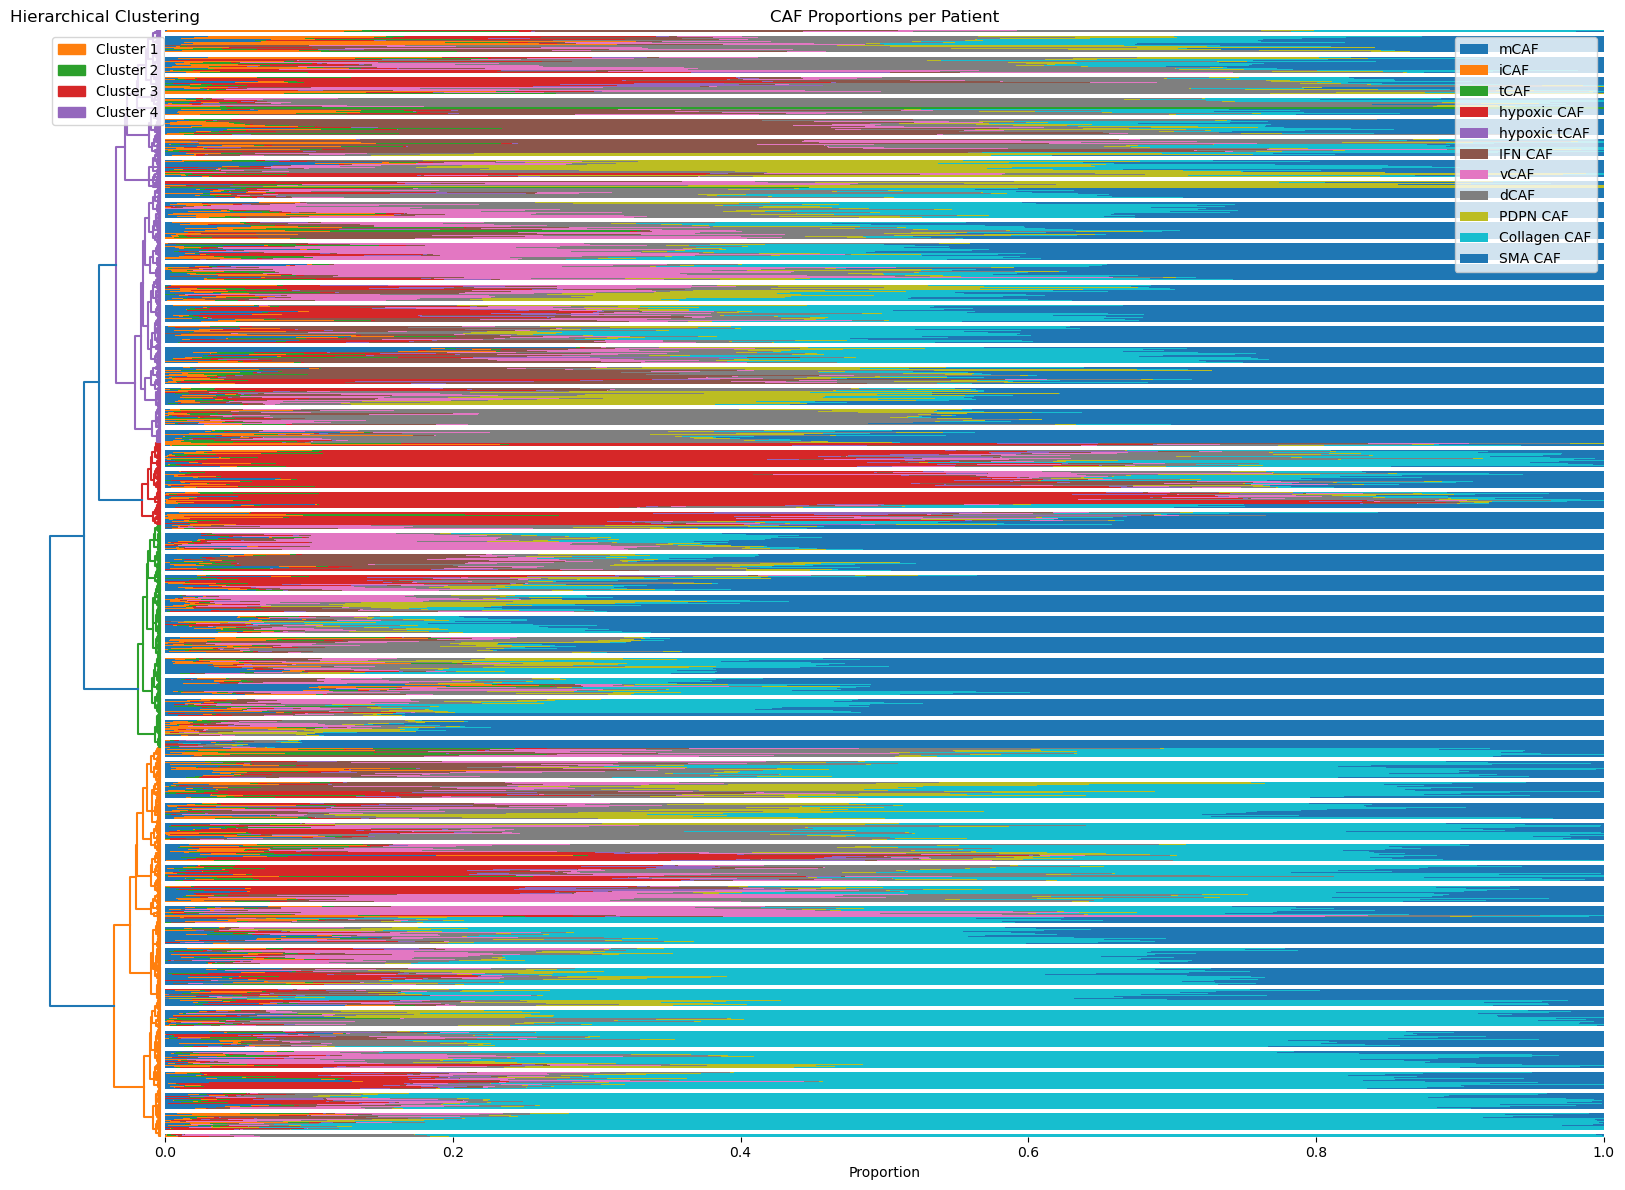

In [5]:
%matplotlib inline
import matplotlib.patches as mpatches

fig, axes = plt.subplots(
    1, 2, figsize=(16, 12),
    gridspec_kw={"width_ratios":[0.5, 6], "wspace": 0},  # <-- wspace=0 removes gap
    sharey=True
)

# First, get the dendrogram info without plotting
ddata = dendrogram(
    Z,
    orientation="right",
    color_threshold=Z[-(4-1), 2],
    no_labels=True,
    no_plot=True
)

# Original leaf positions (spaced by 10)
orig_leaf_pos = np.array(ddata["leaves"])
orig_y = np.arange(len(orig_leaf_pos)) * 10

# Desired leaf positions (0, 1, 2, ..., n-1 to match barh)
new_y = np.arange(len(orig_leaf_pos))

# Build mapping from original y to new y
scale = (new_y.max() - new_y.min()) / (orig_y.max() - orig_y.min())
offset = new_y.min() - orig_y.min() * scale

def rescale_y(y):
    return y * scale + offset

# Rescale icoord (branch coordinates)
icoord_new = [[rescale_y(y) for y in xs] for xs in ddata["icoord"]]

# Flip the x-coordinates (dcoord) by negating and shifting
max_x = max(max(xs) for xs in ddata["dcoord"])
dcoord_flipped = [[-x + max_x for x in xs] for xs in ddata["dcoord"]]

# Plot using flipped x-coordinates
for xs, ys, color in zip(dcoord_flipped, icoord_new, ddata["color_list"]):
    axes[0].plot(xs, ys, color=color)

# map cluster IDs to dendrogram leaf colors
cluster_colors = {}
for leaf_idx, leaf_color in zip(ddata['leaves'], ddata['leaves_color_list']):
    cid = clusters[leaf_idx]
    if cid not in cluster_colors:
        cluster_colors[cid] = leaf_color

# legend for dendrogram clusters
patches = [
    mpatches.Patch(color=cluster_colors[cid], label=f"Cluster {cid}")
    for cid in sorted(cluster_colors)
]

axes[0].legend(handles=patches, loc="upper left")
axes[0].set_title("Hierarchical Clustering")


# Remove axes borders and ticks from dendrogram
axes[0].set_yticks([])
axes[0].set_yticklabels([])
axes[0].set_xticks([])
axes[0].set_xticklabels([])
axes[0].spines['top'].set_visible(False)      # <-- remove borders
axes[0].spines['right'].set_visible(False)
axes[0].spines['bottom'].set_visible(False)
axes[0].spines['left'].set_visible(False)

# Plot proportions
bottom = np.zeros(len(temp_props_ordered), dtype=float)
legend_handles = []  # <-- for legend

for col, color in zip(caf_cols_plotting, caf_palette):
    bars = axes[1].barh(
        y=temp_props_ordered.index,
        width=temp_props_ordered[col].values,
        left=bottom,
        color=color,
        edgecolor="none",
        label=col  # <-- add labels for legend
    )
    legend_handles.append(bars)  # <-- collect handles
    bottom += temp_props_ordered[col].values

axes[1].set_title("CAF Proportions per Patient")
axes[1].set_xlabel("Proportion")
axes[1].set_ylabel("")\
# Fix y-limits to match the bar positions exactly
n_samples = len(temp_props_ordered)
axes[1].set_ylim(-0.5, n_samples - 0.5)  # <-- proper bar alignment
axes[0].set_ylim(-0.5, n_samples - 0.5)  # <-- sync dendrogram

# Add legend
axes[1].legend(loc='upper right', bbox_to_anchor=(1, 1))  # <-- add legend

# Remove borders from proportions graph
axes[1].spines['top'].set_visible(False)      # <-- remove borders
axes[1].spines['right'].set_visible(False)
axes[1].spines['bottom'].set_visible(False)
axes[1].spines['left'].set_visible(False)

plt.tight_layout()
# plt.savefig(os.path.join(BASE_CSV_DIR, "caf_props_clusters.pdf"), format='pdf', dpi=300, bbox_inches='tight')
plt.show()
